# Day 3 — Logistic Regression & Classification Metrics

## Data Preperation and Cleaning

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
Bank_data = pd.read_csv("Bank_Customer_Churn_Prediction.csv")
Bank_data

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [24]:
Bank_data = pd.get_dummies(Bank_data,columns=['country'], drop_first=True)
Bank_data['gender'] = Bank_data['gender'].map({'Male': 0, 'Female': 1})

    country and gender are categorical columns that cause error.
    country: one-hot encoding - no natural order relations
    gende: label encoding - consists of only 2 categories.

In [73]:
Bank_data.isnull().sum()
Bank_data.dropna(inplace=True)
Bank_data.shape

(10000, 12)

No missing values were detected

In [74]:
x = Bank_data.drop(["churn"], axis = 1)
y = Bank_data["churn"]

## Step 1 - Train  a Logistic Regression Model

In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_Scaled = scaler.transform(X_test)
Bank_data.shape


(10000, 12)

Data was scaled since every column had a different range of values, for instance, ages range between 6 and 100, balance can go from thousands to 100 thousands and beyond.

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
predictions = model.predict(X_test_Scaled)
probabilities = model.predict_proba(X_test_Scaled) 

A logistic regressison model was created, trained and predictions were produced using the scaled data.

## Step 2 - Predictions and Confusion Matrix

In [37]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
cm=confusion_matrix(y_test, predictions)
print(cm)

[[1543   64]
 [ 314   79]]


    [TN] - 1543 customers were actually expected to stay and stayed.
    [FP] - 64 customers were expected to stay and churned
    [FN] - 314 customers were expexted to churn but stayed
    [TP] - 79 correctly detected as churners

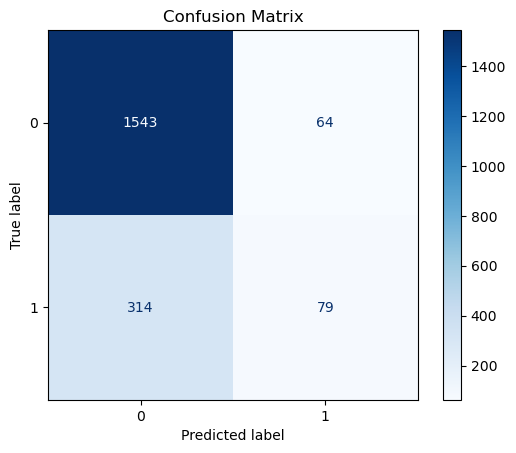

In [38]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

## Step 3 - Precision, Recall, F1

In [56]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



    Interpretation:
    0 [stayed] - The model is good at predicting churners, it is right most of the time and can find 96% of the churners correctly.
    1 [churned] - The model is 55% of the time right when flagging a customer as a churner but is terrible at finding them.
    An 81% precision is good but misleading - the model has seen only 393/2000 churners wich is a very few amout of data to predict on.

## Step 4 - Prescision vs Recall

Recall matters more in this case because losing customers that were actually expected to stay will affect the buisiness revenue for the long run.
Customers staying when they were expected to churn has a less negative impact than losing customers that were expected to stay.

## Step 5 - AUC - ROC

In [75]:
from sklearn.metrics import roc_auc_score, roc_curve

probabilities_model = model.predict_proba(X_test_Scaled)[:,1]

The above code calculates the probability of customers leaving

In [71]:
auc = roc_auc_score(y_test, probabilities_model)
print(auc)

0.7788998829864888


    The above code calculates the accuracy of the model in calculating the probabilties(How many customer actually left out of those the model predicted to leave). 
    The result is avalue between 0 and 1 that reflects the accuracy of the model.
    77% is a good accuracy percentage but can be enhanced.

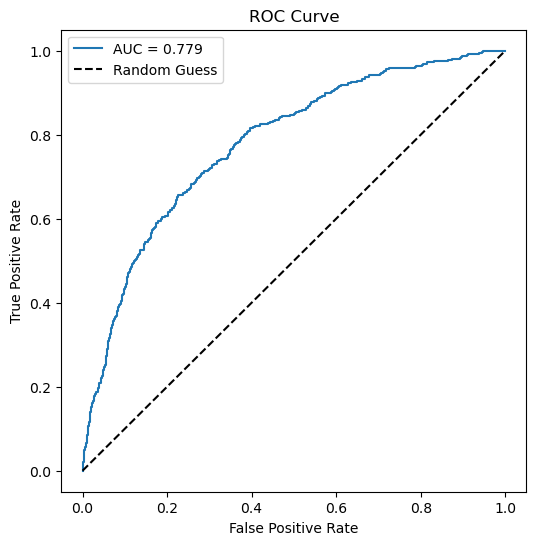

In [72]:
false_pos_rate, true_pos_rate, thresholds = roc_curve(y_test, probabilities_model)

plt.figure(figsize=(6,6))
plt.plot(false_pos_rate, true_pos_rate, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], "k--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

The diagonal represents a model that randomly guesses, the closer the curve is to the diagonal the less accurate and precise it is. This model shows good performance compared to the diagonal